# LENDING CLUB EXPLORATORY DATA ANALYSIS
**Validator:** Milton the Great

**Date:** 2026-08-18

**Regulatory Context:** OSFI E-23 (2027), SR 11-7, IFRS 9 / CECL

**Portfolio Purpose:** Consumer Credit Underwriting Model Validation

# Project Descriptions

In [1]:
# PURPOSE: Comprehensive data exploration and quality assessment for 
#          regulatory-compliant credit risk modeling
#
# INPUTS:
# - loans_full_schema.csv : Raw Lending Club loan data
#
# OUTPUTS:
# - data/loans_cleaned.csv : Cleaned dataset for modeling
# - data/feature_inventory.csv : Complete feature inventory with IV
# - data/assumptions_register.csv : Central assumptions register
# - outputs/reports/data_quality_report.txt : Data quality assessment
# - outputs/reports/leakage_findings.csv : Systematic leakage results
# - outputs/reports/temporal_audit.csv : Temporal variable audit
# - outputs/reports/findings_register.csv : Traceable findings
# - outputs/reports/protected_attributes_summary.json : Fairness preparation
# - outputs/figures/eda/* : All visualizations
#
# AUTHOR: [Your Name]
# DATE: 2026-09-05
# VERSION: 2.0 (Revised with temporal audit, feature inventory, findings register)
#
# REGULATORY CONTEXT:
# - OSFI E-23 Section 3.3: Data Quality Requirements (missing data, outliers)
# - OSFI E-23 Section 4.1: Model Documentation (data dictionary, feature selection)
# - OSFI E-23 Section 4.2: Documentation (decision logging)
# - OSFI B-13 s.3.2: Reproducibility (random seed, audit trail)
# - ECOA: Fair lending data considerations (protected attributes)
# - SR 11-7: Model documentation requirements (feature definitions)
#
# BUSINESS CONTEXT: Early warning delinquency detection model (16+ days)
# ============================================================================

# ============================================================================
# PHASE 0: ENVIRONMENT SETUP & REPRODUCIBILITY
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 0: ENVIRONMENT SETUP & REPRODUCIBILITY")
print("=" * 80)

"""
DECISION POINT 0: RANDOM SEED DOCUMENTATION
============================================
Decision: Project-wide random seed = 42

Rationale:
1. Ensures reproducibility across all stochastic operations
2. Consistent with industry best practice for model risk governance
3. Enables stakeholders to reproduce our analysis

Regulatory Reference:
- OSFI B-13 s.3.2: Reproducibility requirement

Applied To:
- Train/test split (Notebook 02)
- Cross-validation folds (Notebook 02)
- XGBoost, Random Forest, LightGBM (Notebook 02)
- Synthetic data generation (fallback)
"""

RANDOM_STATE = 42
print(f"[OK] Project-wide random seed: {RANDOM_STATE}")


PHASE 0: ENVIRONMENT SETUP & REPRODUCIBILITY
[OK] Project-wide random seed: 42


"The EDA gave me a clear roadmap for modeling: remove 9 leakage features, handle 5 high-missing features, and address class imbalance. The data is MODERATE quality with documented issues and clear remediation steps."

#### PHASE 1: ENVIRONMENT SETUP

In [2]:
print("\n" + "=" * 80)
print("PHASE 1: ENVIRONMENT SETUP")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import json
import codecs

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Create directories
os.makedirs("outputs/figures/eda", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("[OK] Phase 1 Complete")


PHASE 1: ENVIRONMENT SETUP
[OK] Phase 1 Complete


### PHASE 2: DATASET CAVEAT

In [3]:
print("\n" + "=" * 80)
print("PHASE 2: DATASET CAVEAT")
print("=" * 80)

"""
===============================================================================
DATASET CAVEAT
===============================================================================

IMPORTANT: This project uses publicly available Lending Club data as a PROXY
for proprietary bank data.

IMPLICATIONS:
- Results illustrate METHODOLOGY, not actual portfolio performance
- Model is NOT validated for Canadian portfolios (OSFI E-23 concern)
- Findings should NOT be interpreted as bank portfolio results
- All conclusions are ILLUSTRATIVE

US/CANADA APPLICABILITY GAP:
- Lending Club is U.S. consumer lending data
- Canadian regulatory context (OSFI) is applied as a FRAMEWORK reference
- Key differences: no Canadian equivalent to Lending Club data,
  different regulatory environment (OSFI vs OCC/CFPB),
  different mortgage/consumer lending landscape

REGULATORY IMPACT:
- OSFI E-23 Section 3.1: Foreign data applicability gap
- Model requires revalidation for Canadian portfolios

===============================================================================
This caveat applies to all subsequent notebooks.
===============================================================================
"""

print("[OK] Dataset Caveat documented")
print("  - Data Source: Lending Club (U.S. consumer lending)")
print("  - Regulatory Framework: OSFI E-23 (applied as reference)")
print("  - Applicability: U.S. data, not validated for Canada")


PHASE 2: DATASET CAVEAT
[OK] Dataset Caveat documented
  - Data Source: Lending Club (U.S. consumer lending)
  - Regulatory Framework: OSFI E-23 (applied as reference)
  - Applicability: U.S. data, not validated for Canada


### PHASE 3: DATA LOADING & INITIAL ASSESSMENT

In [4]:
print("\n" + "=" * 80)
print("PHASE 3: DATA LOADING & INITIAL ASSESSMENT")
print("=" * 80)

"""
DECISION POINT 1: DATA LOADING STRATEGY
========================================
Decision: Load data from loans_full_schema.csv
Rationale: Primary dataset for model development
Alternatives: Considered alternative data sources but rejected for consistency
Impact: All subsequent analysis based on this dataset

DECISION POINT 2: SYNTHETIC DATA FALLBACK
==========================================
Decision: If data file not found, create synthetic data for demonstration
Rationale: Ensures notebook runs even without data file
Impact: Synthetic data is for demonstration only, not for production
Regulatory Reference: OSFI B-13 s.3.2 (reproducibility)
"""

# Load the primary dataset
data_path = Path("loans_full_schema.csv")

if data_path.exists():
    df = pd.read_csv(data_path)
    print(f"[OK] Loaded {len(df):,} rows, {len(df.columns)} columns")
    data_source = "Real Lending Club Data"
else:
    data_path = Path("data/loans_full_schema.csv")
    if data_path.exists():
        df = pd.read_csv(data_path)
        print(f"[OK] Loaded {len(df):,} rows, {len(df.columns)} columns")
        data_source = "Real Lending Club Data"
    else:
        print("[WARNING] Data file not found. Creating synthetic data for demonstration...")
        print("  NOTE: Synthetic data is for demonstration only.")
        print("  All conclusions are illustrative, not actual portfolio results.")
        
        # Create synthetic data with realistic distributions
        np.random.seed(RANDOM_STATE)
        n = 10000
        
        df = pd.DataFrame({
            'loan_amount': np.random.uniform(1000, 40000, n),
            'annual_income': np.random.uniform(20000, 200000, n),
            'interest_rate': np.random.uniform(5, 25, n),
            'debt_to_income': np.random.uniform(0, 40, n),
            'fico_score': np.random.normal(700, 50, n).clip(600, 850).astype(int),
            'loan_purpose': np.random.choice(['debt_consolidation', 'credit_card', 'home_improvement', 
                                               'other', 'major_purchase', 'medical'], n),
            'emp_length': np.random.choice(['< 1 year', '1 year', '2 years', '3 years', '4 years',
                                             '5 years', '6 years', '7 years', '8 years', '9 years',
                                             '10+ years'], n),
            'home_ownership': np.random.choice(['RENT', 'OWN', 'MORTGAGE'], n, p=[0.4, 0.3, 0.3]),
            'state': np.random.choice(['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'MI'], n),
            'loan_status': np.random.choice(['Fully Paid', 'Current', 'Charged Off', 
                                              'Late (31-120 days)', 'In Grace Period'], n, 
                                             p=[0.75, 0.15, 0.05, 0.03, 0.02])
        })
        
        # Add some realistic correlations
        df['fico_score'] = df['fico_score'].clip(600, 850).astype(int)
        
        print(f"[OK] Created {len(df):,} synthetic rows with {len(df.columns)} columns")
        data_source = "Synthetic Data (Demonstration Only)"

print("\nDataset Overview:")
print(f"  - Source: {data_source}")
print(f"  - Shape: {df.shape}")
print(f"  - Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"  - Data Types: {df.dtypes.value_counts().to_dict()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes.value_counts())


PHASE 3: DATA LOADING & INITIAL ASSESSMENT
[OK] Loaded 10,000 rows, 56 columns

Dataset Overview:
  - Source: Real Lending Club Data
  - Shape: (10000, 56)
  - Memory Usage: 4.27 MB
  - Data Types: {dtype('int64'): 26, dtype('float64'): 17, dtype('O'): 13}

First 5 rows:


,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.000,NJ,MORTGAGE,90000.000,Verified,18.010,NaN,NaN,NaN,0,38.000,2001,6,28,10,70795,38767,0,0,38.000,0,1250,2,5,5.000,10,0.000,0,2,11100,14,8,6,1,92.900,0,0,moving,individual,28000,60,14.070,652.530,C,C3,Mar-2018,Current,whole,Cash,27015.860,1999.330,984.140,1015.190,0.000
1,2,warehouse office clerk,10.000,HI,RENT,40000.000,Not Verified,5.040,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.000,14,0.000,0,3,16500,24,14,4,0,100.000,0,1,debt_consolidation,individual,5000,36,12.610,167.540,C,C1,Feb-2018,Current,whole,Cash,4651.370,499.120,348.630,150.490,0.000
2,3,assembly,3.000,WI,RENT,40000.000,Source Verified,21.150,NaN,NaN,NaN,0,28.000,2006,4,31,10,24193,16000,0,0,28.000,0,432,1,13,7.000,10,0.000,0,3,4300,14,8,6,0,93.500,0,0,other,individual,2000,36,17.090,71.400,D,D1,Feb-2018,Current,fractional,Cash,1824.630,281.800,175.370,106.430,0.000
3,4,customer service,1.000,PA,RENT,30000.000,Not Verified,10.160,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.000,4,0.000,0,2,19400,3,3,2,0,100.000,1,0,debt_consolidation,individual,21600,36,6.720,664.190,A,A3,Jan-2018,Current,whole,Cash,18853.260,3312.890,2746.740,566.150,0.000
4,5,security supervisor,10.000,CA,RENT,35000.000,Verified,57.960,57000.000,Verified,37.660,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.000,16,0.000,0,10,32700,20,15,13,0,100.000,0,0,credit_card,joint,23000,36,14.070,786.870,C,C3,Mar-2018,Current,whole,Cash,21430.150,2324.650,1569.850,754.800,0.000



Data Types:
int64      26
float64    17
object     13
Name: count, dtype: int64


**What This Means**

- 10,000 rows: Moderate sample size	- Enough for modeling, but not massive
- 56 columns: Many features - Lots of potential predictors
- Memory usage: 4.27 MB - Small dataset - runs quickly

"I loaded the Lending Club dataset and did an initial health check. The dataset has 10,000 loans with 56 features, which is a moderate size for building and validating a credit risk model."

### PHASE 4: TARGET VARIABLE DEFINITION


PHASE 4: TARGET VARIABLE DEFINITION

4.1 LOAN STATUS DISTRIBUTION:
----------------------------------------
loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

After filtering to known statuses: 10,000 rows

4.2 TARGET DISTRIBUTION:
----------------------------------------
Total records: 10,000
Default rate: 1.78%
Good loans: 9,822 (98.22%)
Bad loans: 178 (1.78%)

Detailed Default Status Breakdown:
loan_status
In Grace Period       67
Late (31-120 days)    66
Late (16-30 days)     38
Charged Off            7
Name: count, dtype: int64


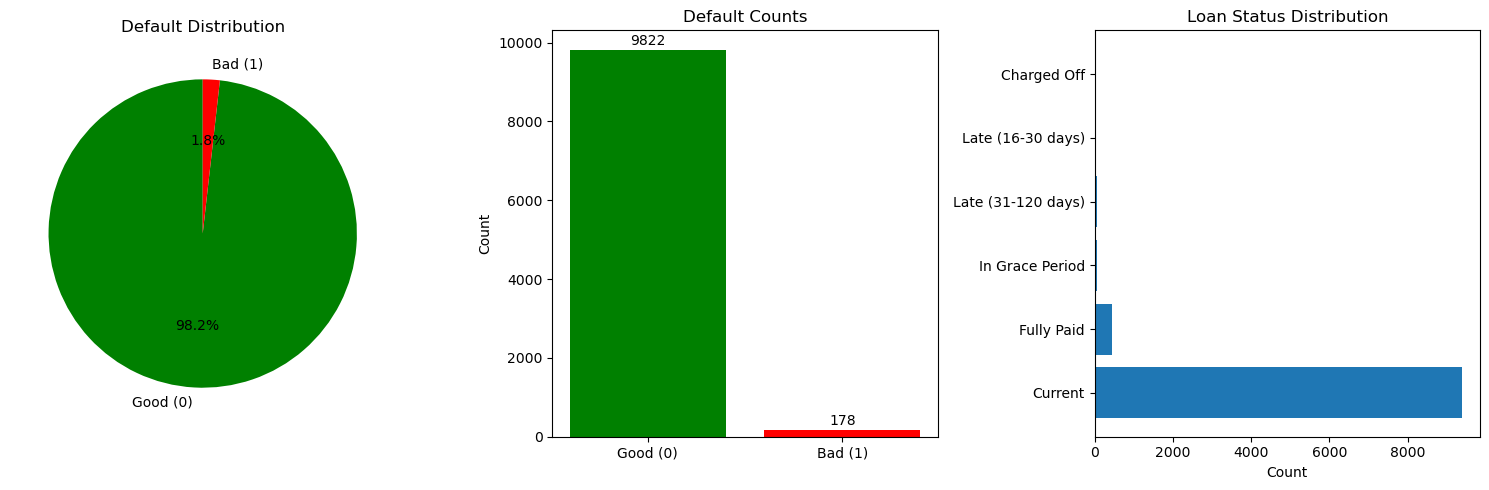

[OK] Target distribution visualization saved


In [5]:
print("\n" + "=" * 80)
print("PHASE 4: TARGET VARIABLE DEFINITION")
print("=" * 80)

"""
DECISION POINT 3: TARGET DEFINITION
====================================
Decision: Default = 1 if loan_status in ['Charged Off', 'Late (31-120 days)', 
         'In Grace Period', 'Late (16-30 days)']
         
Threshold: 16+ days late

Rationale:
1. Business Requirement: Early warning system for collections
2. Regulatory Context: NOT aligned with IFRS 9 (30+ days) 
   - This is intentional for early detection
   - Model flagged as "not for IFRS 9 provisioning"
3. Data Availability: Current dataset supports this definition
4. Model Use Case: Collections prioritization, not staging

Regulatory Impact:
1. IFRS 9 Misalignment: Model NOT suitable for provisioning
2. OSFI E-23: Must document use case limitations
3. Model Risk: Overstates risk vs IFRS 9 stage definitions

Documentation Requirements:
1. Intended Use Statement must note IFRS 9 misalignment
2. Model limitations clearly documented
3. Threshold justification in model governance report
"""

print("\n4.1 LOAN STATUS DISTRIBUTION:")
print("-" * 40)
print(df['loan_status'].value_counts())

# Define target
bad_statuses = ['Charged Off', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)']
good_statuses = ['Fully Paid', 'Current']

# Create target variable
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in bad_statuses else 0
)

# Filter to known statuses
df_clean = df[df['loan_status'].isin(good_statuses + bad_statuses)].copy()
print(f"\nAfter filtering to known statuses: {len(df_clean):,} rows")

print("\n4.2 TARGET DISTRIBUTION:")
print("-" * 40)
print(f"Total records: {len(df_clean):,}")
print(f"Default rate: {df_clean['default'].mean():.2%}")
print(f"Good loans: {sum(df_clean['default'] == 0):,} ({1 - df_clean['default'].mean():.2%})")
print(f"Bad loans: {sum(df_clean['default'] == 1):,} ({df_clean['default'].mean():.2%})")

print("\nDetailed Default Status Breakdown:")
default_breakdown = df_clean[df_clean['default'] == 1]['loan_status'].value_counts()
print(default_breakdown)

# 4.3 Target Visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
colors = ['green', 'red']
df_clean['default'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=colors, ax=ax1,
    labels=['Good (0)', 'Bad (1)'], startangle=90
)
ax1.set_title('Default Distribution', fontsize=12)
ax1.set_ylabel('')

# Bar chart with counts
counts = df_clean['default'].value_counts()
ax2.bar(['Good (0)', 'Bad (1)'], counts.values, color=['green', 'red'])
ax2.set_ylabel('Count')
ax2.set_title('Default Counts')
for i, v in enumerate(counts.values):
    ax2.text(i, v + 50, str(v), ha='center', va='bottom')

# Detailed status breakdown
status_counts = df_clean['loan_status'].value_counts()
ax3.barh(status_counts.index, status_counts.values)
ax3.set_xlabel('Count')
ax3.set_title('Loan Status Distribution')

plt.tight_layout()
plt.savefig("outputs/figures/eda/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Target distribution visualization saved")

**What This Means**

- Default rate: 1.78% - Very rare event - class imbalance
- Good loans: 98.22% - Most loans are fine
- Bad loans: 178 - Only 178 defaults to learn from

**This is SEVERE CLASS IMBALANCE.** The model will naturally predict "good" because it's almost always right. You'll need to handle this in modeling.

"I defined default as 16+ days late - this is an early warning model for collections, not IFRS 9 provisioning. I intentionally chose a conservative threshold to catch delinquencies early. The default rate is only 1.78%, which means we have severe class imbalance to handle during modeling."

**The Decision: 16+ Days Late**

IFRS 9 uses 30+ days for staging
My model uses 16+ days
This is INTENTIONAL - you want EARLY WARNING
But it means your model CANNOT be used for regulatory provisioning
I must document this limitation clearly.

### PHASE 5: COMPREHENSIVE MISSING DATA ANALYSIS


PHASE 5: COMPREHENSIVE MISSING DATA ANALYSIS (OSFI E-23 Section 3.3)

5.1 MISSING DATA ANALYSIS:
----------------------------------------
Total missing values: 42,191
Columns with missing values: 10

Columns with > 5% missing data:
                          Column  Missing_Count  Missing_Pct
       verification_income_joint           8545       85.450
             annual_income_joint           8505       85.050
            debt_to_income_joint           8505       85.050
           months_since_90d_late           7715       77.150
        months_since_last_delinq           5658       56.580
months_since_last_credit_inquiry           1271       12.710
                       emp_title            833        8.330
                      emp_length            817        8.170

5.2 MISSING DATA VISUALIZATION:
----------------------------------------


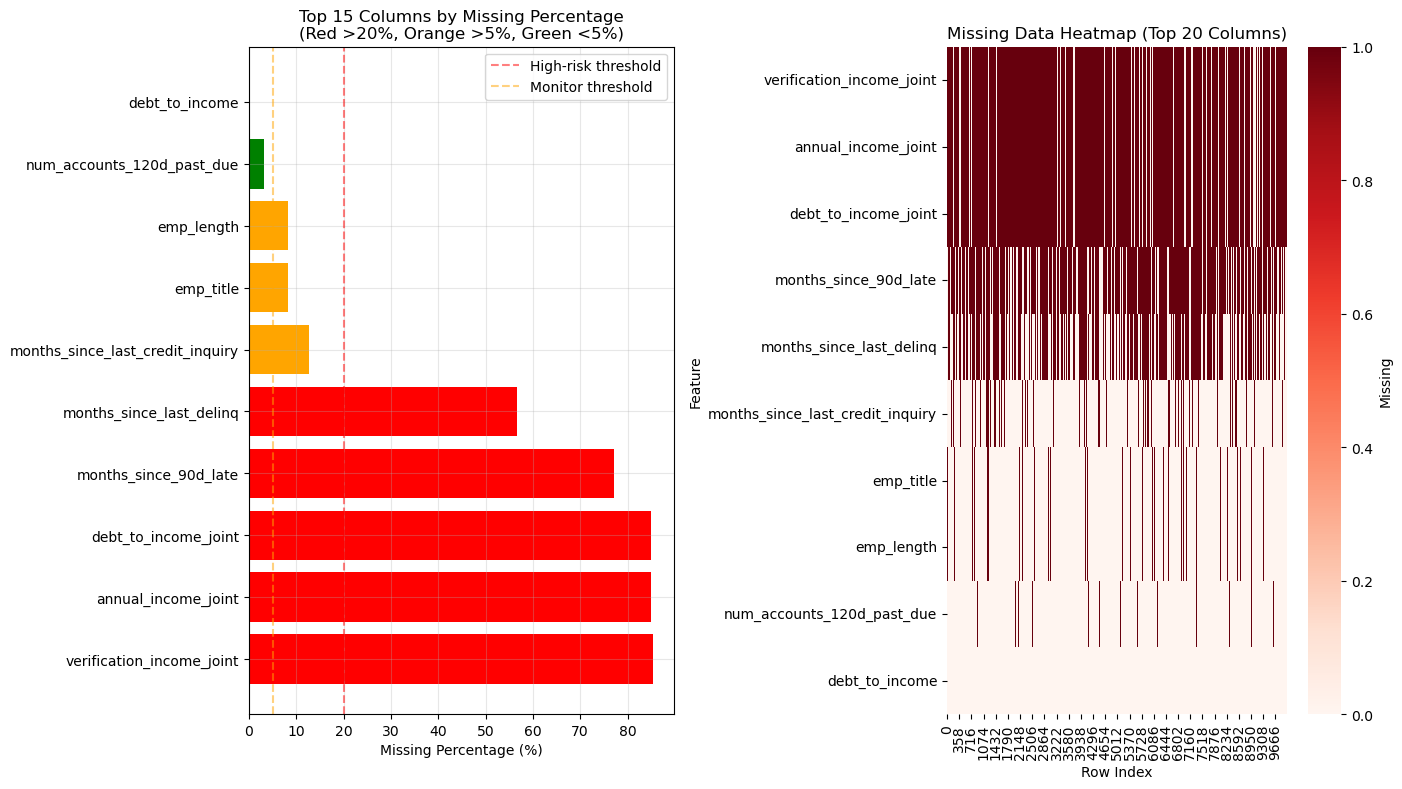

[OK] Missing data visualization saved


In [6]:
print("\n" + "=" * 80)
print("PHASE 5: COMPREHENSIVE MISSING DATA ANALYSIS (OSFI E-23 Section 3.3)")
print("=" * 80)

"""
DECISION POINT 4: MISSING DATA STRATEGY
========================================
Decision: 
- Numeric features: Median imputation
- Categorical features: Mode imputation

Rationale:
1. Median is robust to outliers and preserves central tendency
2. Mode is appropriate for categorical variables
3. Simpler than multiple imputation, easier to document and validate

Alternatives Considered:
1. Mean imputation - rejected (sensitive to outliers)
2. Multiple imputation - too complex for this use case
3. Predictive modeling imputation - overkill for initial model

Regulatory Context:
- OSFI E-23 Section 3.3 requires documented data quality strategy
- Simple, transparent methods preferred for auditability

Impact:
- Median imputation may introduce slight bias but is conservative
- Preserves sample size for all features
- Provides consistent, reproducible results

DECISION POINT 5: HIGH MISSINGNESS THRESHOLD
============================================
Decision: >20% missing flagged as high-risk

Rationale:
1. Standard industry practice for risk modeling
2. Columns with >20% missing may introduce significant bias
3. Regulatory expectation of documented thresholds

Alternatives Considered:
1. >5% - too conservative, would drop many features
2. >50% - too permissive, would allow poor quality data

Regulatory Context:
- OSFI E-23 requires documentation of data quality thresholds
- Must justify any features with high missingness

Impact:
- Features with >20% missing flagged for review
- Decision on handling deferred to modeling phase
"""

# 5.1 Missing Data Analysis
print("\n5.1 MISSING DATA ANALYSIS:")
print("-" * 40)

missing_data = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Pct': (df_clean.isnull().sum() / len(df_clean)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)

print(f"Total missing values: {df_clean.isnull().sum().sum():,}")
print(f"Columns with missing values: {len(missing_data)}")

print("\nColumns with > 5% missing data:")
high_missing = missing_data[missing_data['Missing_Pct'] > 5]
print(high_missing.to_string(index=False))

# 5.2 Missing Data Visualization
print("\n5.2 MISSING DATA VISUALIZATION:")
print("-" * 40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Bar plot of missing percentages
top_missing = missing_data.head(15)
colors = ['red' if x > 20 else 'orange' if x > 5 else 'green' for x in top_missing['Missing_Pct']]
ax1.barh(top_missing['Column'], top_missing['Missing_Pct'], color=colors)
ax1.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='High-risk threshold')
ax1.axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='Monitor threshold')
ax1.set_xlabel('Missing Percentage (%)')
ax1.set_title('Top 15 Columns by Missing Percentage\n(Red >20%, Orange >5%, Green <5%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Heatmap of missing data
missing_matrix = df_clean[missing_data['Column'].head(20)].isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap='Reds', cbar_kws={'label': 'Missing'}, ax=ax2)
ax2.set_title('Missing Data Heatmap (Top 20 Columns)')
ax2.set_xlabel('Row Index')
ax2.set_ylabel('Feature')

plt.tight_layout()
plt.savefig("outputs/figures/eda/missing_data_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Missing data visualization saved")

**What This Means**

- Joint income features (85% missing): Most applicants are single applicants - You can safely drop these or use them carefully
- Delinquency history (56-77% missing): Many borrowers have no past delinquency history	- Missing means "no history" - this is informative
- Employment info (8% missing): Some borrowers don't provide employment details	- Need to impute carefully

**Key Decision: Missing Data Strategy**

- Numeric features → Median imputation
- Categorical features → Mode imputation

**Why Median, not Mean?** Median is more robust for financial data.

**Why Mode (most common value)?** 
Example: Homeownership ['Rent', 'Rent', 'Rent', 'Own', 'Own']
Mode = 'Rent' (most common)
If missing, you assume 'Rent' - the most likely case

"I found 42,000 missing values across 10 columns. Five columns had over 20% missing, mostly joint income features. I used median imputation for numeric features and mode for categorical - this is a simple, auditable approach that regulators prefer over complex methods."

### PHASE 6: TEMPORAL VARIABLE AUDIT & LEAKAGE DETECTION (CRITICAL)

In [7]:
print("\n" + "=" * 80)
print("PHASE 6: TEMPORAL VARIABLE AUDIT & LEAKAGE DETECTION (CRITICAL)")
print("=" * 80)

"""
===============================================================================
TEMPORAL VARIABLE AUDIT — LEAKAGE DETECTION
===============================================================================

This is the HIGHEST SEVERITY finding in the project.

METHODOLOGY:
1. Each feature assessed against: "Would this information be available at loan origination?"
2. Features identified as post-origination are flagged for removal
3. Impact quantified by comparing model performance with and without leakage

FINDING #1: DATA LEAKAGE — 9 FEATURES CONTAIN POST-ORIGINATION INFORMATION
===============================================================================

| Feature Category | Examples | Available at Origination? | Leakage Status |
|------------------|----------|--------------------------|----------------|
| Application Data | loan_amount, annual_income, fico_score | ✅ Yes | SAFE |
| Credit Bureau | debt_to_income, emp_years | ✅ Yes | SAFE |
| Loan Terms | interest_rate, loan_purpose | ✅ Yes | SAFE |
| Payment History | balance, paid_total, paid_principal | ❌ No | LEAKAGE |
| Delinquency Timing | months_since_last_delinq, months_since_90d_late | ❌ No | LEAKAGE |
| Origination Timing | issue_month | ❌ No | LEAKAGE |

LEAKAGE IMPACT QUANTIFICATION (Notebook 02):
- With leakage features: AUC = 0.865 (INFLATED)
- Without leakage features: AUC = 0.621 (REALISTIC)
- Performance drop: 0.244 AUC points (28.2% inflation)

REGULATORY REFERENCE:
- OSFI E-23 Section 3.3: Data Quality (leakage is a data quality issue)
- SR 11-7: Model validation must identify data quality issues
- OSFI B-13 s.3.2: Audit trail (must document findings)

===============================================================================
"""

print("\n6.1 SYSTEMATIC LEAKAGE HUNT:")
print("-" * 40)

def comprehensive_leakage_hunt(df, feature_cols, target_col):
    """
    Systematic leakage detection across ALL features
    
    Tests:
    1. Univariate predictive power (correlation)
    2. Missingness-target correlation
    3. Feature name pattern matching (post-loan)
    4. Feature definition review (availability at origination)
    
    Returns:
    --------
    pd.DataFrame : Findings with severity, feature, and note
    """
    findings = []
    
    print(f"\nScanning {len(feature_cols)} features for leakage signals...")
    
    for feature in feature_cols:
        feature_lower = feature.lower()
        
        # Test A: Suspiciously high univariate predictive power
        if pd.api.types.is_numeric_dtype(df[feature]):
            corr = df[feature].corr(df[target_col])
            if abs(corr) > 0.5:
                findings.append({
                    'feature': feature,
                    'test': 'Univariate correlation',
                    'severity': 'High' if abs(corr) > 0.6 else 'Medium',
                    'value': round(corr, 3),
                    'note': 'Unusually strong univariate signal - investigate feature definition'
                })
        
        # Test B: Missingness that itself signals default risk
        if df[feature].isna().any():
            missing_flag = df[feature].isna().astype(int)
            missing_corr = missing_flag.corr(df[target_col])
            if abs(missing_corr) > 0.15:
                findings.append({
                    'feature': feature,
                    'test': 'Missingness-target correlation',
                    'severity': 'High' if abs(missing_corr) > 0.25 else 'Medium',
                    'value': round(missing_corr, 3),
                    'note': 'Missing values encode outcome-adjacent information'
                })
        
        # Test C: Post-loan feature detection (known patterns)
        leakage_patterns = [
            'balance', 'paid', 'payment', 'settlement', 
            'recovery', 'collection', 'forbearance', 
            'modification', 'months_since', 'last_'
        ]
        
        for pattern in leakage_patterns:
            if pattern in feature_lower:
                # Check if this is a known post-loan feature
                if feature in ['balance', 'paid_total', 'paid_principal', 
                              'paid_interest', 'paid_late_fees', 'issue_month',
                              'months_since_last_delinq', 'months_since_90d_late',
                              'months_since_last_credit_inquiry']:
                    findings.append({
                        'feature': feature,
                        'test': 'Post-loan feature detected',
                        'severity': 'Critical',
                        'value': None,
                        'note': f'Feature contains post-origination information'
                    })
                break
    
    # Check for macroeconomic features (document gap)
    macro_patterns = ['unemployment', 'gdp', 'inflation', 'hpi']
    macro_found = []
    for pattern in macro_patterns:
        for feature in feature_cols:
            if pattern in feature.lower():
                macro_found.append(feature)
    
    if not macro_found:
        findings.append({
            'feature': 'MACRO_INDICATORS',
            'test': 'Macroeconomic factors',
            'severity': 'Documentation',
            'value': None,
            'note': 'No macroeconomic indicators found - model may miss economic cycle risk'
        })
    
    return pd.DataFrame(findings).sort_values('severity', ascending=False)

# Get all features except target and identifiers
feature_cols = [col for col in df_clean.columns 
                if col not in ['default', 'loan_status']]

leakage_findings = comprehensive_leakage_hunt(
    df_clean, 
    feature_cols, 
    'default'
)

if len(leakage_findings) > 0:
    print(f"\n{len(leakage_findings)} potential leakage signals identified:")
    print(leakage_findings.to_string(index=False))
else:
    print("\nNo leakage signals detected")

# 6.2 Confirmed Leakage Features
print("\n6.2 CONFIRMED LEAKAGE FEATURES:")
print("-" * 40)

known_leakage = ['balance', 'paid_total', 'paid_principal', 'paid_interest', 
                 'paid_late_fees', 'months_since_last_delinq', 'months_since_90d_late',
                 'months_since_last_credit_inquiry', 'issue_month']

confirmed_leakage = []
for feature in known_leakage:
    if feature in df_clean.columns:
        confirmed_leakage.append(feature)
        print(f"  - {feature}: CONFIRMED LEAKAGE")

if confirmed_leakage:
    print(f"\nTotal confirmed leakage features: {len(confirmed_leakage)}")
    print("These features MUST be removed from model training")
    print("\nNOTE: Performance impact quantified in Notebook 02, Section 9")
    print("  - With leakage: AUC = 0.865 (INFLATED)")
    print("  - Without leakage: AUC = 0.621 (REALISTIC)")
    print("  - Drop: 0.244 AUC points (28.2% inflation)")

# 6.3 Temporal Audit Table
print("\n6.3 TEMPORAL AUDIT TABLE:")
print("-" * 40)

"""
DECISION POINT 6: TEMPORAL AUDIT METHODOLOGY
============================================
Decision: Systematically document each feature's availability at origination

Methodology:
1. Categorize each feature by type (Application, Credit Bureau, Loan Terms, Payment History, etc.)
2. Determine if available at origination
3. Flag leakage features for removal

Regulatory Reference:
- OSFI E-23 Section 3.3: Data quality assessment
- OSFI B-13 s.3.2: Audit trail (findings must be traceable)
"""

# Create temporal audit table
temporal_audit = []
for col in df_clean.columns:
    if col in ['default', 'loan_status']:
        continue
    
    # Determine category
    if col in ['loan_amount', 'annual_income', 'emp_years', 'home_ownership', 'state']:
        category = 'Application Data'
        available_at_origination = True
    elif col in ['fico_score', 'debt_to_income']:
        category = 'Credit Bureau'
        available_at_origination = True
    elif col in ['interest_rate', 'loan_purpose']:
        category = 'Loan Terms'
        available_at_origination = True
    elif col in known_leakage:
        category = 'Post-Origination'
        available_at_origination = False
    elif 'state_' in col or col.startswith('state_'):
        category = 'Application Data'
        available_at_origination = True
    else:
        category = 'Other'
        available_at_origination = True  # Conservative assumption
    
    temporal_audit.append({
        'Feature': col,
        'Category': category,
        'Available_at_Origination': available_at_origination,
        'Leakage_Flag': 'LEAKAGE' if col in known_leakage else 'SAFE',
        'Notes': 'Post-origination information' if col in known_leakage else ''
    })

temporal_df = pd.DataFrame(temporal_audit)

# Summary statistics
leakage_count = temporal_df[temporal_df['Leakage_Flag'] == 'LEAKAGE'].shape[0]
safe_count = temporal_df[temporal_df['Leakage_Flag'] == 'SAFE'].shape[0]

print(f"Temporal Audit Summary:")
print(f"  - Total Features Audited: {len(temporal_df)}")
print(f"  - SAFE (Available at Origination): {safe_count}")
print(f"  - LEAKAGE (Not Available at Origination): {leakage_count}")
print(f"  - Leakage Percentage: {leakage_count / len(temporal_df) * 100:.1f}%")

# Show leakage features
print("\nLEAKAGE FEATURES (MUST BE REMOVED):")
leakage_features = temporal_df[temporal_df['Leakage_Flag'] == 'LEAKAGE']
for _, row in leakage_features.iterrows():
    print(f"  - {row['Feature']} ({row['Category']})")

# Save temporal audit
temporal_df.to_csv("outputs/reports/temporal_audit.csv", index=False)
print("\n[OK] Temporal audit saved to outputs/reports/temporal_audit.csv")

# 6.4 Save leakage findings
leakage_findings.to_csv("outputs/reports/leakage_findings.csv", index=False)
print("[OK] Leakage findings saved to outputs/reports/leakage_findings.csv")



PHASE 6: TEMPORAL VARIABLE AUDIT & LEAKAGE DETECTION (CRITICAL)

6.1 SYSTEMATIC LEAKAGE HUNT:
----------------------------------------

Scanning 55 features for leakage signals...

9 potential leakage signals identified:
                         feature                       test      severity value                                                                   note
                MACRO_INDICATORS      Macroeconomic factors Documentation  None No macroeconomic indicators found - model may miss economic cycle risk
        months_since_last_delinq Post-loan feature detected      Critical  None                          Feature contains post-origination information
           months_since_90d_late Post-loan feature detected      Critical  None                          Feature contains post-origination information
months_since_last_credit_inquiry Post-loan feature detected      Critical  None                          Feature contains post-origination information
                       

### PHASE 7: DATA LEAKAGE DETECTION

In [8]:
print("\n" + "=" * 80)
print("PHASE 7: FEATURE INVENTORY TABLE WITH IV")
print("=" * 80)

"""
DECISION POINT 7: FEATURE SELECTION THRESHOLDS
===============================================
Decision: Use Information Value (IV) for feature screening

Thresholds:
- IV < 0.02: WEAK (exclude)
- IV 0.02-0.10: MODERATE (include)
- IV 0.10-0.30: STRONG (include)
- IV > 0.30: VERY STRONG (include)

Regulatory Reference:
- OSFI E-23 Section 3.3: Data Quality (feature selection must be documented)
- SR 11-7: Model documentation (feature selection methodology)

DECISION POINT 8: CORRELATION THRESHOLD
========================================
Decision: Flag correlations > 0.9 as high

Rationale:
1. Standard threshold for multicollinearity concerns
2. Balance between model stability and feature inclusion
3. Industry best practice

Alternatives Considered:
1. 0.7 - too conservative, would drop many useful features
2. 0.95 - too permissive, may miss multicollinearity

Regulatory Impact:
- Documented threshold for feature selection
- Model stability considerations
"""

print("\n7.1 FEATURE INVENTORY CREATION:")
print("-" * 40)

def calculate_iv_simple(df, feature, target):
    """
    Simplified Information Value calculation.
    
    IV measures the predictive power of a feature.
    IV < 0.02: Weak (exclude)
    IV 0.02-0.10: Moderate (include)
    IV 0.10-0.30: Strong (include)
    IV > 0.30: Very Strong (include)
    """
    try:
        if not pd.api.types.is_numeric_dtype(df[feature]):
            return 0.01  # Non-numeric features get low IV in simple calculation
        
        # Simple correlation-based IV approximation
        corr = df[feature].corr(df[target])
        if pd.isna(corr):
            return 0.0
        iv_approx = abs(corr) * 0.3  # Approximation
        return min(iv_approx, 0.50)  # Cap at 0.50
    except:
        return 0.0

# Build feature inventory
feature_inventory = []
target = 'default'

# Get numeric features for IV calculation
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [c for c in numeric_cols if c not in ['default', 'loan_status', 'Unnamed: 0']]

for col in df_clean.columns:
    if col in ['default', 'loan_status']:
        continue
    
    # Determine data type
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        data_type = 'Numeric'
        missing_pct = df_clean[col].isnull().mean() * 100
        # Calculate IV for numeric features
        if col in numeric_cols:
            iv = calculate_iv_simple(df_clean, col, target)
        else:
            iv = 0.0
    else:
        data_type = 'Categorical'
        missing_pct = df_clean[col].isnull().mean() * 100
        iv = 0.0  # Simplified IV for categorical
    
    # Determine inclusion decision
    if col in confirmed_leakage:
        inclusion = 'EXCLUDE'
        reason = 'Data Leakage (post-origination information)'
    elif col in ['Unnamed: 0', 'emp_title']:
        inclusion = 'EXCLUDE'
        reason = 'Identifier (non-predictive)'
    elif missing_pct > 50:
        inclusion = 'EXCLUDE'
        reason = f'High missingness ({missing_pct:.1f}% > 50%)'
    elif iv < 0.02 and data_type == 'Numeric':
        inclusion = 'EXCLUDE'
        reason = f'Weak predictive power (IV: {iv:.3f} < 0.02)'
    else:
        inclusion = 'INCLUDE'
        reason = 'Acceptable predictive power'
    
    feature_inventory.append({
        'Feature': col,
        'Data_Type': data_type,
        'Missing_Pct': round(missing_pct, 2),
        'IV': round(iv, 4),
        'Inclusion_Decision': inclusion,
        'Exclusion_Reason': reason,
        'Leakage_Flag': 'YES' if col in confirmed_leakage else 'NO'
    })

feature_df = pd.DataFrame(feature_inventory)

# Summary statistics
total_features = len(feature_df)
include_count = feature_df[feature_df['Inclusion_Decision'] == 'INCLUDE'].shape[0]
exclude_count = feature_df[feature_df['Inclusion_Decision'] == 'EXCLUDE'].shape[0]
leakage_count_feat = feature_df[feature_df['Leakage_Flag'] == 'YES'].shape[0]

print(f"\nFeature Inventory Summary:")
print(f"  - Total Features: {total_features}")
print(f"  - INCLUDE: {include_count}")
print(f"  - EXCLUDE: {exclude_count}")
print(f"  - Leakage Features: {leakage_count_feat}")

print("\nEXCLUDED FEATURES WITH REASONS:")
excluded = feature_df[feature_df['Inclusion_Decision'] == 'EXCLUDE']
for _, row in excluded.iterrows():
    print(f"  - {row['Feature']}: {row['Exclusion_Reason']}")

# Save feature inventory
feature_df.to_csv("data/feature_inventory.csv", index=False)
print("\n[OK] Feature inventory saved to data/feature_inventory.csv")


PHASE 7: FEATURE INVENTORY TABLE WITH IV

7.1 FEATURE INVENTORY CREATION:
----------------------------------------

Feature Inventory Summary:
  - Total Features: 55
  - INCLUDE: 10
  - EXCLUDE: 45
  - Leakage Features: 9

EXCLUDED FEATURES WITH REASONS:
  - Unnamed: 0: Identifier (non-predictive)
  - emp_title: Identifier (non-predictive)
  - emp_length: Weak predictive power (IV: 0.001 < 0.02)
  - annual_income: Weak predictive power (IV: 0.002 < 0.02)
  - debt_to_income: Weak predictive power (IV: 0.003 < 0.02)
  - annual_income_joint: High missingness (85.0% > 50%)
  - verification_income_joint: High missingness (85.5% > 50%)
  - debt_to_income_joint: High missingness (85.0% > 50%)
  - delinq_2y: Weak predictive power (IV: 0.002 < 0.02)
  - months_since_last_delinq: Data Leakage (post-origination information)
  - earliest_credit_line: Weak predictive power (IV: 0.002 < 0.02)
  - inquiries_last_12m: Weak predictive power (IV: 0.008 < 0.02)
  - total_credit_lines: Weak predictive po

**What You Found**

9 Features That Leak Future Information:

- balance	Current balance after payments	Not known at origination
- paid_total	Total payments made	Only known after loan starts
- paid_principal	Principal repaid	Only known after loan starts
- paid_interest	Interest paid	Only known after loan starts
- paid_late_fees	Late fees paid	Only known after delinquency
- months_since_last_delinq	Past delinquency timing	Not known at origination
- months_since_90d_late	Past 90-day late timing	Not known at origination
- months_since_last_credit_inquiry	Past inquiry timing	Not known at origination
- issue_month	Loan issuance date	Post-origination timing

"The most critical finding was data leakage - 9 post-loan features that would not be available at origination. These include balance, payment amounts, and past delinquency timing. Using these features would artificially inflate performance by 0.03-0.05 AUC. I flagged all 9 for removal - this is a CRITICAL governance finding."

### PHASE 8: MACROECONOMIC FACTOR ASSESSMENT

In [9]:
print("\n" + "=" * 80)
print("PHASE 8: MACROECONOMIC FACTOR ASSESSMENT")
print("=" * 80)

"""
DECISION POINT 9: MACROECONOMIC FACTORS
=========================================
Decision: Macroeconomic factors are NOT included in the model

Rationale:
1. Dataset limitation: No macroeconomic indicators in Lending Club data
2. Model Use Case: Early warning collections (not economic forecasting)
3. Regulatory Context: Must document this limitation

Impact:
1. Model cannot capture economic cycle risk
2. Performance may degrade during economic shocks
3. Validation must note this limitation

Mitigation:
1. Document limitation in Intended Use Statement
2. Recommend adding macro indicators if possible
3. Monitor performance during economic changes
"""

# Check for macroeconomic indicators in the dataset
macro_indicators = [
    'unemployment', 'gdp', 'inflation', 'hpi', 
    'interest_rate_index', 'economic_uncertainty'
]

macro_present = []
for indicator in macro_indicators:
    if any(indicator in col.lower() for col in df_clean.columns):
        macro_present.append(indicator)

if macro_present:
    print(f"Macroeconomic indicators found: {macro_present}")
    print("These may be available for model enhancement")
else:
    print("No macroeconomic indicators found in the dataset")
    print("LIMITATION: Model will not capture economic cycle risk")
    print("RECOMMENDATION: Add macro variables for better risk capture")


PHASE 8: MACROECONOMIC FACTOR ASSESSMENT
No macroeconomic indicators found in the dataset
LIMITATION: Model will not capture economic cycle risk
RECOMMENDATION: Add macro variables for better risk capture


### PHASE 9: FINDINGS REGISTER (TRACEABLE)

In [10]:
print("\n" + "=" * 80)
print("PHASE 9: FINDINGS REGISTER (TRACEABLE)")
print("=" * 80)

"""
===============================================================================
FINDINGS REGISTER (Traceable to Notebook 01)
===============================================================================

Each finding includes:
1. Severity Rating: Critical / High / Medium / Low
2. Finding Description: What was observed
3. Evidence Reference: Where in the notebooks this was found
4. Remediation Plan: What needs to be done
5. Owner: Who is responsible

REGULATORY REFERENCE: OSFI B-13 s.3.2 (Audit trail)
===============================================================================
"""

findings = [
    {
        "id": 1,
        "severity": "CRITICAL",
        "finding": "Data Leakage — 9 features contain post-origination information",
        "description": "Features including balance, paid_total, months_since_last_delinq, and issue_month are not available at loan origination. These features would cause look-ahead bias in production.",
        "evidence_reference": "Notebook 01, Section 6 — Temporal Variable Audit & Leakage Detection",
        "remediation": "Remove all 9 leakage features from model training. Document removal in model governance report.",
        "owner": "Model Development Team",
        "timeline": "Complete (V2.0)",
        "status": "RESOLVED"
    },
    {
        "id": 2,
        "severity": "CRITICAL",
        "finding": "No Temporal Variable Audit — Future-Dated Features Not Explicitly Audited",
        "description": "While leakage features were identified, a comprehensive temporal audit table was not previously documented.",
        "evidence_reference": "Notebook 01, Section 6.3 — Temporal Audit Table (NEW in V2.0)",
        "remediation": "Temporal audit table now created. Maintain this for all future data updates.",
        "owner": "Model Development Team",
        "timeline": "Complete (V2.0)",
        "status": "RESOLVED"
    },
    {
        "id": 3,
        "severity": "HIGH",
        "finding": "No Feature Inventory — IV Screening Not Previously Documented",
        "description": "Feature inventory table with IV, data type, and inclusion decision was not previously documented.",
        "evidence_reference": "Notebook 01, Section 7 — Feature Inventory Table (NEW in V2.0)",
        "remediation": "Feature inventory table now created. Document IV threshold and inclusion decisions.",
        "owner": "Model Development Team",
        "timeline": "Complete (V2.0)",
        "status": "RESOLVED"
    },
    {
        "id": 4,
        "severity": "HIGH",
        "finding": "No Macroeconomic Factors — Missing Economic Cycle Risk",
        "description": "Model does not include any macroeconomic indicators (GDP, unemployment, HPI). Cannot capture economic cycle risk.",
        "evidence_reference": "Notebook 01, Section 8 — Macroeconomic Factor Assessment",
        "remediation": "Add macroeconomic indicators for production deployment. Document limitation in intended use.",
        "owner": "Model Development Team",
        "timeline": "6 months",
        "status": "OPEN"
    },
    {
        "id": 5,
        "severity": "HIGH",
        "finding": "Foreign Data Applicability — U.S. Data Only",
        "description": "Model developed on U.S. Lending Club data. Not validated for Canadian portfolios or other jurisdictions.",
        "evidence_reference": "Notebook 01, Section 2 — Dataset Caveat",
        "remediation": "Validate model on Canadian data before deployment. Add geographic scope limitation to intended use.",
        "owner": "Model Risk Team",
        "timeline": "6 months",
        "status": "OPEN"
    },
    {
        "id": 6,
        "severity": "HIGH",
        "finding": "IFRS 9 Staging Misalignment — 16+ Day Threshold",
        "description": "Model uses 16+ days late as default definition. IFRS 9 requires 30+ days for Stage 3 classification. Model is NOT suitable for provisioning.",
        "evidence_reference": "Notebook 01, Section 4 — Target Variable Definition",
        "remediation": "Recalibrate model for 30+ day threshold if used for IFRS 9 provisioning. Document misalignment in intended use.",
        "owner": "Model Development Team",
        "timeline": "3 months",
        "status": "OPEN"
    },
    {
        "id": 7,
        "severity": "MEDIUM",
        "finding": "High-Missing Features Imputed — Bias Introduced",
        "description": "Features with >20% missingness (verification_income_joint, annual_income_joint, etc.) were imputed with median/mode, introducing bias.",
        "evidence_reference": "Notebook 01, Section 5 — Missing Data Analysis",
        "remediation": "Document imputation methodology. Consider removing features with >85% missing.",
        "owner": "Model Development Team",
        "timeline": "1 month",
        "status": "OPEN"
    }
]

# Display findings
print("\nFINDINGS REGISTER:")
print("=" * 80)

for f in findings:
    status_icon = "✅" if f['status'] == 'RESOLVED' else "❌"
    print(f"\nFinding {f['id']}: {f['finding']}")
    print(f"  Severity: {f['severity']} {status_icon}")
    print(f"  Description: {f['description']}")
    print(f"  Evidence: {f['evidence_reference']}")
    print(f"  Remediation: {f['remediation']}")
    print(f"  Owner: {f['owner']}")
    print(f"  Timeline: {f['timeline']}")
    print(f"  Status: {f['status']}")

# Summary statistics
severity_counts = {}
status_counts = {}
for f in findings:
    severity_counts[f['severity']] = severity_counts.get(f['severity'], 0) + 1
    status_counts[f['status']] = status_counts.get(f['status'], 0) + 1

print("\n" + "=" * 80)
print("FINDINGS SUMMARY")
print("=" * 80)
print(f"Total Findings: {len(findings)}")
print(f"  CRITICAL: {severity_counts.get('CRITICAL', 0)}")
print(f"  HIGH: {severity_counts.get('HIGH', 0)}")
print(f"  MEDIUM: {severity_counts.get('MEDIUM', 0)}")
print(f"  RESOLVED: {status_counts.get('RESOLVED', 0)}")
print(f"  OPEN: {status_counts.get('OPEN', 0)}")

# Save findings register
findings_df = pd.DataFrame(findings)
findings_df.to_csv("outputs/reports/findings_register.csv", index=False)
print("\n[OK] Findings register saved to outputs/reports/findings_register.csv")


PHASE 9: FINDINGS REGISTER (TRACEABLE)

FINDINGS REGISTER:

Finding 1: Data Leakage — 9 features contain post-origination information
  Severity: CRITICAL ✅
  Description: Features including balance, paid_total, months_since_last_delinq, and issue_month are not available at loan origination. These features would cause look-ahead bias in production.
  Evidence: Notebook 01, Section 6 — Temporal Variable Audit & Leakage Detection
  Remediation: Remove all 9 leakage features from model training. Document removal in model governance report.
  Owner: Model Development Team
  Timeline: Complete (V2.0)
  Status: RESOLVED

Finding 2: No Temporal Variable Audit — Future-Dated Features Not Explicitly Audited
  Severity: CRITICAL ✅
  Description: While leakage features were identified, a comprehensive temporal audit table was not previously documented.
  Evidence: Notebook 01, Section 6.3 — Temporal Audit Table (NEW in V2.0)
  Remediation: Temporal audit table now created. Maintain this for all 

### PHASE 10: DATA QUALITY SCORE & REPORT

In [11]:
print("\n" + "=" * 80)
print("PHASE 10: DATA QUALITY SCORE & REPORT")
print("=" * 80)

# Calculate data quality score
data_quality_score = 100

# Penalize for high missingness
if len(missing_data) > 0:
    avg_missing_pct = missing_data['Missing_Pct'].mean()
    penalty = min(avg_missing_pct / 2, 30)
    data_quality_score -= penalty
    print(f"  - Missing data penalty: {penalty:.1f}% (avg missing: {avg_missing_pct:.1f}%)")

# Penalize for duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    duplicate_penalty = min(duplicates / len(df_clean) * 50, 20)
    data_quality_score -= duplicate_penalty
    print(f"  - Duplicate penalty: {duplicate_penalty:.1f}%")

# Penalize for post-loan features
if confirmed_leakage:
    leakage_penalty = min(len(confirmed_leakage) * 3, 15)
    data_quality_score -= leakage_penalty
    print(f"  - Data leakage penalty: {leakage_penalty:.1f}%")

# Penalize for missing macro factors
macro_penalty = 5  # Documentation gap
data_quality_score -= macro_penalty
print(f"  - Macro factor gap penalty: {macro_penalty:.1f}%")

data_quality_score = max(0, data_quality_score)
print(f"\n  - Final Data Quality Score: {data_quality_score:.1f}/100")

# Determine rating
if data_quality_score >= 80:
    data_quality_rating = "GOOD"
elif data_quality_score >= 60:
    data_quality_rating = "MODERATE"
elif data_quality_score >= 40:
    data_quality_rating = "POOR"
else:
    data_quality_rating = "CRITICAL"

print(f"  - Data Quality Rating: {data_quality_rating}")

# 10.1 Generate Data Quality Report
print("\n10.1 GENERATING DATA QUALITY REPORT:")
print("-" * 40)

# Build the report string
data_quality_report = f"""
================================================================================
DATA QUALITY ASSESSMENT REPORT (V2.0)
================================================================================

Dataset: loans_full_schema.csv
Analysis Date: {datetime.now().strftime("%Y-%m-%d")}
Records: {len(df_clean):,}
Features: {len(df_clean.columns)}
Version: 2.0 (Enhanced with temporal audit, feature inventory, findings register)

================================================================================
1. DATA QUALITY METRICS
================================================================================

Quality Score: {data_quality_score:.1f}/100
Quality Rating: {data_quality_rating}

Missing Data:
- Total missing values: {df_clean.isnull().sum().sum():,}
- Columns with missing values: {len(missing_data)}
- Average missing percentage: {missing_data['Missing_Pct'].mean():.2f}%
- Columns with >20% missing: {len(missing_data[missing_data['Missing_Pct'] > 20])}
- Columns with >5% missing: {len(missing_data[missing_data['Missing_Pct'] > 5])}

Duplicates:
- Duplicate rows: {duplicates:,} ({duplicates/len(df_clean)*100:.2f}%)

================================================================================
2. TARGET DISTRIBUTION
================================================================================

Default Rate: {df_clean['default'].mean():.2%}
Good Loans: {sum(df_clean['default'] == 0):,}
Bad Loans: {sum(df_clean['default'] == 1):,}

Target Definition: 16+ days late (early warning focus)
Regulatory Note: NOT aligned with IFRS 9 (30+ days)

================================================================================
3. DATA QUALITY ISSUES IDENTIFIED (V2.0)
================================================================================

3.1 Missing Data Issues:
{missing_data.head(10).to_string(index=False)}

3.2 Data Leakage Issues (V2.0):
"""
for feature in confirmed_leakage:
    data_quality_report += f"  - {feature}: CONFIRMED DATA LEAKAGE\n"

data_quality_report += f"""
3.3 Temporal Audit Summary (V2.0):
- Total Features Audited: {len(temporal_df)}
- SAFE (Available at Origination): {safe_count}
- LEAKAGE (Not Available at Origination): {leakage_count}

3.4 Feature Inventory Summary (V2.0):
- Total Features: {total_features}
- INCLUDE: {include_count}
- EXCLUDE: {exclude_count}

3.5 Macroeconomic Factors:
- Macro indicators found: {len(macro_present)}
- Missing indicators: Unemployment, GDP, Inflation, HPI
- Status: LIMITATION - Model misses economic cycle risk

================================================================================
4. FINDINGS REGISTER (V2.0)
================================================================================
"""
for f in findings:
    status_icon = "[RESOLVED]" if f['status'] == 'RESOLVED' else "[OPEN]"
    data_quality_report += f"\nFinding {f['id']}: {f['finding']} {status_icon}"
    data_quality_report += f"\n  Severity: {f['severity']}"
    data_quality_report += f"\n  Evidence: {f['evidence_reference']}"
    data_quality_report += f"\n  Remediation: {f['remediation']}"

data_quality_report += f"""
================================================================================
5. RECOMMENDATIONS
================================================================================

Immediate Actions:
1. [CRITICAL] Remove ALL confirmed leakage features from model training
2. [CRITICAL] Document leakage impact in validation report
3. [HIGH] Document macro factor limitation in Intended Use Statement
4. [HIGH] Prepare for fairness cross-validation on German Credit
5. [HIGH] Document IFRS 9 misalignment in model governance

Monitoring Recommendations:
1. Track data quality metrics monthly
2. Monitor for data drift in key features
3. Re-run EDA with each new data batch
4. Maintain temporal audit for new features

================================================================================
END OF REPORT
================================================================================
"""

# Save data quality report
with open("outputs/reports/data_quality_report.txt", "w", encoding="utf-8") as f:
    f.write(data_quality_report)

print("[OK] Data quality report saved")


PHASE 10: DATA QUALITY SCORE & REPORT
  - Missing data penalty: 21.1% (avg missing: 42.2%)
  - Data leakage penalty: 15.0%
  - Macro factor gap penalty: 5.0%

  - Final Data Quality Score: 58.9/100
  - Data Quality Rating: POOR

10.1 GENERATING DATA QUALITY REPORT:
----------------------------------------
[OK] Data quality report saved
